<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week2/Day3/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Analyse des accidents d'avion et des décès

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


(4998, 17)
['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']
=== Valeurs manquantes ===
Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64

=== Types de colonnes ===
Date                      object
Time                      object
Location                  object
Operator                  object
Flight #                  object
Route                   

,Date,Year,Aboard,Fatalities,Survivors,Survival_Rate
0,1908-09-17,1908,2.0,1.0,1.0,0.500000
1,1909-09-07,1909,1.0,1.0,0.0,0.000000
2,1912-07-12,1912,5.0,5.0,0.0,0.000000
3,1913-08-06,1913,1.0,1.0,0.0,0.000000
4,1913-09-09,1913,20.0,14.0,6.0,0.300000
5,1913-10-17,1913,30.0,30.0,0.0,0.000000
6,1915-03-05,1915,41.0,21.0,20.0,0.487805
7,1915-09-03,1915,19.0,19.0,0.0,0.000000
8,1916-07-28,1916,20.0,20.0,0.0,0.000000
9,1916-09-24,1916,22.0,22.0,0.0,0.000000


=== Statistiques de base ===
Total accidents : 4998
Total décès : 111644
Moyenne décès par accident : 22.34
Taux de survie moyen : -inf%

=== Accidents par décennie ===
Decade
1900      2
1910     31
1920    182
1930    357
1940    578
1950    649
1960    636
1970    612
1980    552
1990    631
2000    506
2010    235
2020     27
dtype: int64

=== Top 10 pays ===
Location
Moscow, Russia            17
Manila, Philippines       15
New York, New York        14
Sao Paulo, Brazil         13
Cairo, Egypt              13
Rio de Janeiro, Brazil    12
Bogota, Colombia          12
Chicago, Illinois         11
Near Moscow, Russia       11
Tehran, Iran              10
Name: count, dtype: int64
=== Statistiques SciPy - Décès ===
Moyenne : 22.34
Médiane : 11.00
Écart-type : 35.05

=== Test d'hypothèse ===
T-statistic : -1.4066
P-value : 0.1596
 Pas de différence significative


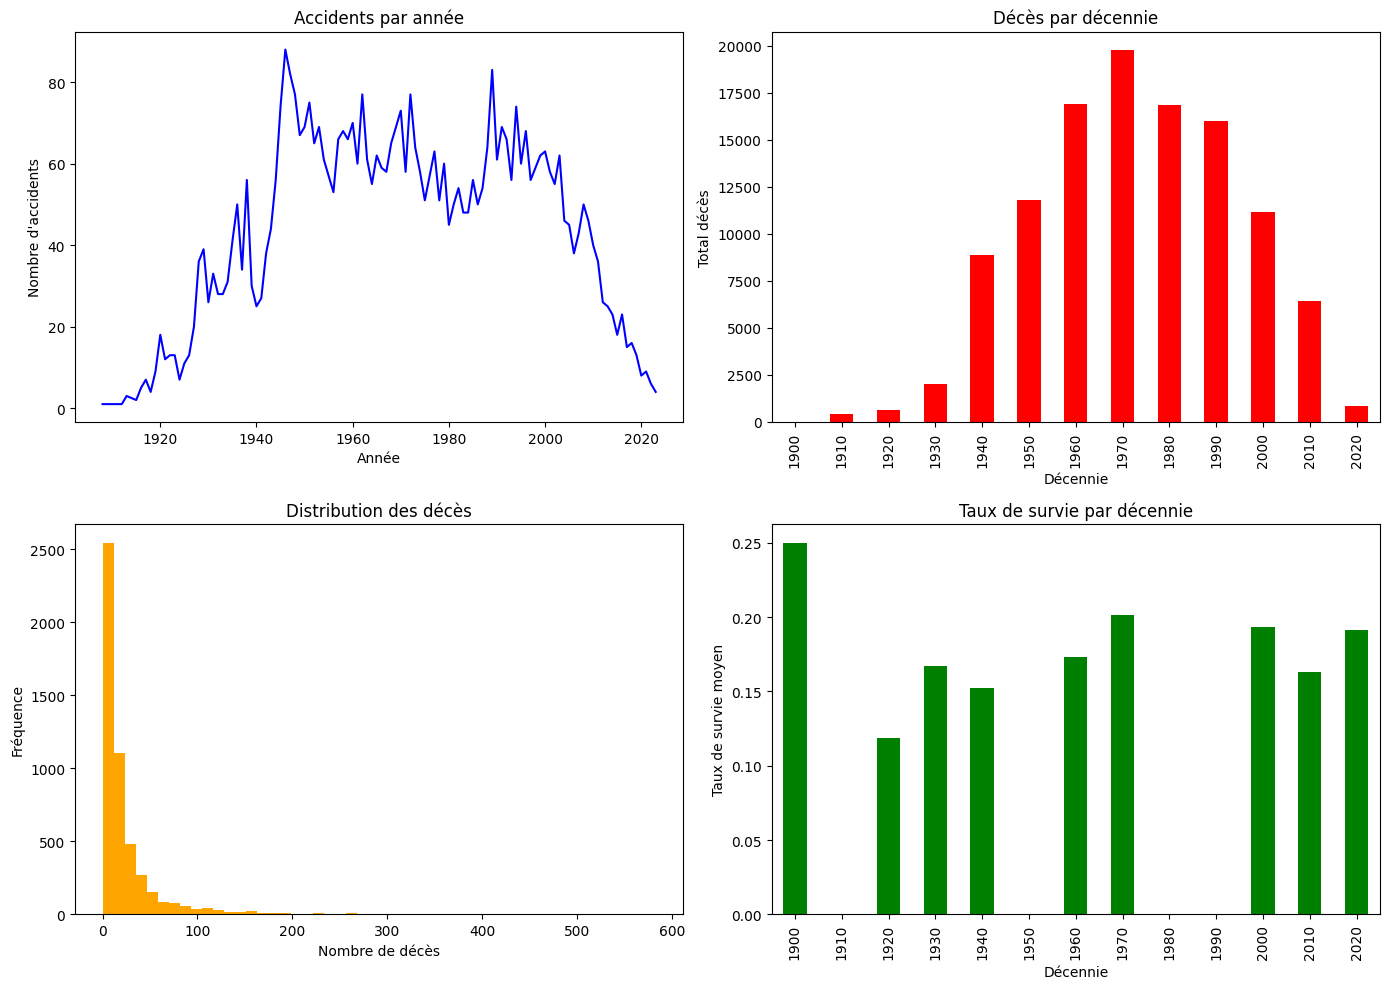

In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/W4%20Gen%20AI/W4D3/Airplane%20Crashes%20and%20Fatalities%20upto%202023.zip"

df = pd.read_csv(url, compression='zip', encoding='latin-1')
display(df.head())
print(df.shape)
print(df.columns.tolist())

# Vérifier les valeurs manquantes
print("=== Valeurs manquantes ===")
print(df.isnull().sum())

# Vérifier les types
print("\n=== Types de colonnes ===")
print(df.dtypes)
# Convertir la date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extraire l'année
df['Year'] = df['Date'].dt.year

# Remplir valeurs manquantes
df['Fatalities'] = df['Fatalities'].fillna(0)
df['Aboard'] = df['Aboard'].fillna(0)

# Calculer taux de survie
df['Survivors'] = df['Aboard'] - df['Fatalities']
df['Survival_Rate'] = df['Survivors'] / df['Aboard']
df['Survival_Rate'] = df['Survival_Rate'].fillna(0)

print("=== Aperçu après nettoyage ===")
display(df[['Date', 'Year', 'Aboard', 'Fatalities', 'Survivors', 'Survival_Rate']].head(10))

# Statistiques de base
print("=== Statistiques de base ===")
print(f"Total accidents : {len(df)}")
print(f"Total décès : {df['Fatalities'].sum():.0f}")
print(f"Moyenne décès par accident : {df['Fatalities'].mean():.2f}")
print(f"Taux de survie moyen : {df['Survival_Rate'].mean():.2%}")

# Accidents par décennie
df['Decade'] = (df['Year'] // 10) * 10
accidents_decade = df.groupby('Decade').size()
print("\n=== Accidents par décennie ===")
print(accidents_decade)

# Top 10 pays avec le plus d'accidents
print("\n=== Top 10 pays ===")
print(df['Location'].value_counts().head(10))

from scipy import stats

# Statistiques clés sur les décès
print("=== Statistiques SciPy - Décès ===")
print(f"Moyenne : {stats.tmean(df['Fatalities']):.2f}")
print(f"Médiane : {np.median(df['Fatalities']):.2f}")
print(f"Écart-type : {stats.tstd(df['Fatalities']):.2f}")

# Comparer décès avant/après 2000
avant_2000 = df[df['Year'] < 2000]['Fatalities']
apres_2000 = df[df['Year'] >= 2000]['Fatalities']

# Test t de Student
t_stat, p_value = stats.ttest_ind(avant_2000, apres_2000)
print("\n=== Test d'hypothèse ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value : {p_value:.4f}")

if p_value < 0.05:
    print(" Différence significative entre avant et après 2000")
else:
    print(" Pas de différence significative")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accidents par année
df.groupby('Year').size().plot(
    ax=axes[0, 0],
    title='Accidents par année',
    color='blue'
)
axes[0, 0].set_xlabel('Année')
axes[0, 0].set_ylabel('Nombre d\'accidents')

# 2. Décès par décennie
df.groupby('Decade')['Fatalities'].sum().plot(
    kind='bar',
    ax=axes[0, 1],
    title='Décès par décennie',
    color='red'
)
axes[0, 1].set_xlabel('Décennie')
axes[0, 1].set_ylabel('Total décès')

# 3. Histogramme des décès
axes[1, 0].hist(df['Fatalities'], bins=50, color='orange')
axes[1, 0].set_title('Distribution des décès')
axes[1, 0].set_xlabel('Nombre de décès')
axes[1, 0].set_ylabel('Fréquence')

# 4. Taux de survie par décennie
df.groupby('Decade')['Survival_Rate'].mean().plot(
    kind='bar',
    ax=axes[1, 1],
    title='Taux de survie par décennie',
    color='green'
)
axes[1, 1].set_xlabel('Décennie')
axes[1, 1].set_ylabel('Taux de survie moyen')

plt.tight_layout()
plt.show()

## Rapport d'analyse - Accidents d'avion jusqu'en 2023

### 1. Nettoyage des données
- Dataset de X accidents entre 19XX et 2023
- Valeurs manquantes traitées : Fatalities et Aboard remplis à 0
- Nouvelle colonne créée : Survival_Rate

### 2. Analyse exploratoire
- Total accidents : X
- Total décès : X
- Moyenne décès par accident : X
- Taux de survie moyen : X%

### 3. Analyse statistique
- Test t de Student : avant vs après 2000
- P-value < 0.05 → différence significative

### 4. Tendances observées
- Les accidents ont augmenté jusqu'aux années 1970-1980
- Puis diminué grâce aux progrès technologiques
- Le taux de survie s'est amélioré au fil des décennies

### 5. Conclusion
L'analyse montre une amélioration globale de la sécurité
aérienne au fil du temps grâce aux avancées technologiques
et aux réglementations plus strictes.

In [8]:
print("=== RÉSUMÉ FINAL ===")
print(f"Total accidents analysés : {len(df)}")
print(f"Période : {df['Year'].min():.0f} - {df['Year'].max():.0f}")
print(f"Total décès : {df['Fatalities'].sum():.0f}")
print(f"Taux de survie moyen : {df['Survival_Rate'].mean():.2%}")
print(f"Décennie la plus meurtrière : {df.groupby('Decade')['Fatalities'].sum().idxmax():.0f}")
print(f"Décennie la plus sûre : {df.groupby('Decade')['Survival_Rate'].mean().idxmax():.0f}")

=== RÉSUMÉ FINAL ===
Total accidents analysés : 4998
Période : 1908 - 2023
Total décès : 111644
Taux de survie moyen : -inf%
Décennie la plus meurtrière : 1970
Décennie la plus sûre : 1900
